# Comparative Epistemic Reasoning Analysis

Compares annotation distributions across **4 groups** (Human, Llama 70B, GPT 120B, Qwen 80B)
using the LLM jury output.

**Workflow**: set the two filter parameters in the Parameters cell, then run all cells in order.
To try a different threshold, change it and re-run from *Load Data* onward.

| `CONSENSUS_THRESHOLD` | Meaning |
|---|---|
| `0.0` | No filter — keep all annotated spans (any judge) |
| `0.5` | Majority — winning label chosen by > 50 % of covering judges |
| `0.75` | 75 % — winning label chosen by ≥ 75 % of covering judges |

`MIN_COVERING` (default `5`): minimum number of judges that must have annotated a span
for the ratio filter to apply. Ignored when `CONSENSUS_THRESHOLD = 0.0`.
Prevents a single isolated judge from passing a "75 % consensus" filter.

## 1 · Imports

In [33]:
import json
import sys
from pathlib import Path
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

sys.path.insert(0, str(Path('.').resolve()))
from jury.preprocessor import load_case
from jury.config import LABEL_MAP

## 2 · Parameters

**Only this cell needs to change between runs.**

In [34]:
# ── Consensus filter ─────────────────────────────────────────────────────────
CONSENSUS_THRESHOLD = 0.7   # 0.0 = no filter | 0.5 = majority | 0.75 = 75%
MIN_COVERING        = 5     # min judges covering a span for the ratio filter to apply
                            # (ignored when CONSENSUS_THRESHOLD = 0.0)

# ── Paths ────────────────────────────────────────────────────────────────────
ROOT              = Path('.')
JURY_OUTPUT_HUMAN = ROOT / 'jury_output'
JURY_OUTPUT_LLM   = ROOT / 'jury_output_llm'
CASES_HUMAN       = ROOT / 'cases'
CASES_LLM         = ROOT / 'cases_llm'
PLOTS_DIR         = ROOT / 'plots'

# ── Groups ───────────────────────────────────────────────────────────────────
GROUPS = {
    'Human':     {'source': 'human'},
    'Llama 70B': {'source': 'llm', 'model_dir': 'meta-llama-3.3-70b-instruct'},
    'GPT 120B':  {'source': 'llm', 'model_dir': 'openai-gpt-oss-120b'},
    'Qwen 80B':  {'source': 'llm', 'model_dir': 'qwen-qwen3-next-80b-a3b-instruct'},
}
GROUP_NAMES  = list(GROUPS.keys())
GROUP_COLORS = ['#4CAF50', '#FF9800', '#2196F3', '#9C27B0']

# ── Label taxonomy ───────────────────────────────────────────────────────────
MACRO = {
    'ABD': ['ABD_SELECTIVE', 'ABD_CREATIVE', 'ABD_VISUAL', 'ABD_CAUSAL'],
    'DED': ['DED_HYPOTHETICO', 'DED_ALGORITHMIC', 'DED_HIERARCHICAL', 'DED_VALIDATION'],
    'IND': ['IND_PATTERN', 'IND_INTUITION', 'IND_BAYESIAN', 'IND_CASEBASED'],
}
LABEL_ORDER = [lbl for labels in MACRO.values() for lbl in labels]  # 12 labels, ordered

LABEL_COLORS = {
    'ABD_SELECTIVE':    '#FF4D4D',
    'ABD_CREATIVE':     '#FF7043',
    'ABD_VISUAL':       '#FF9800',
    'ABD_CAUSAL':       '#FFC107',
    'DED_HYPOTHETICO':  '#AB47BC',
    'DED_ALGORITHMIC':  '#7E57C2',
    'DED_HIERARCHICAL': '#5C6BC0',
    'DED_VALIDATION':   '#3F51B5',
    'IND_PATTERN':      '#66BB6A',
    'IND_INTUITION':    '#26A69A',
    'IND_BAYESIAN':     '#29B6F6',
    'IND_CASEBASED':    '#42A5F5',
}
MACRO_COLORS = {'ABD': '#FF6B35', 'DED': '#7E57C2', 'IND': '#43A047'}


def plot_path(name: str) -> Path:
    """Build the save path for a plot, encoding the active filter settings."""
    return PLOTS_DIR / f'{name}_thr{CONSENSUS_THRESHOLD}_mincov{MIN_COVERING}.png'

## 3 · Core Functions

In [35]:
# ── Path helpers ─────────────────────────────────────────────────────────────

def case_id_to_name(case_id: str) -> str:
    """'1990_Case_19' → '1990 Case 19'"""
    return case_id.replace('_', ' ')


def get_case_text_path(case_id: str, group_cfg: dict) -> Path:
    case_name = case_id_to_name(case_id)
    if group_cfg['source'] == 'human':
        return CASES_HUMAN / f'{case_name}.md'
    model_dir = group_cfg['model_dir']
    return CASES_LLM / case_name / f'{case_name}__{model_dir}.md'


def get_jury_dir(case_id: str, group_cfg: dict) -> Path:
    if group_cfg['source'] == 'human':
        return JURY_OUTPUT_HUMAN / case_id
    return JURY_OUTPUT_LLM / case_id / group_cfg['model_dir']


# ── Judge file loader ─────────────────────────────────────────────────────────

def load_judge_files(case_id: str, group_cfg: dict) -> list:
    """Return list of annotation lists, one per judge. Skips failed / missing judges."""
    jury_dir = get_jury_dir(case_id, group_cfg)
    if not jury_dir.exists():
        return []

    summary_path = jury_dir / f'{case_id}_jury_summary.json'
    failed_ids = set()
    if summary_path.exists():
        summary = json.loads(summary_path.read_text(encoding='utf-8'))
        for v in summary.get('voters', []):
            if v.get('failed'):
                failed_ids.add(v['voter_id'])

    all_annotations = []
    for i in range(1, 16):
        if i in failed_ids:
            continue
        judge_path = jury_dir / f'{case_id}_Judge{i:03d}.json'
        if not judge_path.exists():
            continue
        raw = json.loads(judge_path.read_text(encoding='utf-8'))
        all_annotations.append(raw.get('annotations', []))
    return all_annotations


# ── Segment computation (mirrors comparison_tool/static/app.js logic) ─────────

def compute_segments(judge_annotations: list, full_text_len: int) -> list:
    """
    Segment the text at every annotation boundary from all judges.
    For each segment, record which unique judges cover its midpoint and with which labels.
    Counting unique judges (not raw annotation count) avoids double-counting.
    """
    bps = {0, full_text_len}
    for anns in judge_annotations:
        for ann in anns:
            for (s, e) in ann.get('ranges', []):
                bps.add(max(0, s))
                bps.add(min(full_text_len, e))

    sorted_bps = sorted(bps)
    segments = []
    for i in range(len(sorted_bps) - 1):
        start, end = sorted_bps[i], sorted_bps[i + 1]
        if start >= end:
            continue
        mid = (start + end) // 2

        judge_labels: dict = {}
        for judge_idx, anns in enumerate(judge_annotations):
            for ann in anns:
                if any(s <= mid < e for (s, e) in ann.get('ranges', [])):
                    if judge_idx not in judge_labels:
                        judge_labels[judge_idx] = []
                    judge_labels[judge_idx].append(ann['label_name'])

        if judge_labels:
            segments.append({'start': start, 'end': end, 'judge_labels': judge_labels})
    return segments


# ── Consensus filter ──────────────────────────────────────────────────────────

def filter_segments(segments: list, threshold: float, min_covering: int) -> list:
    """
    Filter segments by consensus.

    When threshold = 0.0: no filter — keep every segment with at least 1 judge.

    When threshold > 0.0: keep only segments where BOTH conditions hold:
      1. n_covering >= min_covering  (enough judges actually annotated this span)
      2. agreement  >= threshold     (of those judges, enough agree on the winning label)

    agreement = n_winners / n_covering, using the covering count as denominator.
    A span covered by 10 judges where 8 agree → 80 % → passes threshold 0.75.
    """
    result = []
    for seg in segments:
        label_to_judges: dict = defaultdict(set)
        for judge_idx, labels in seg['judge_labels'].items():
            for lbl in labels:
                label_to_judges[lbl].add(judge_idx)

        n_covering    = len(seg['judge_labels'])
        winning_label = max(label_to_judges, key=lambda l: len(label_to_judges[l]))
        n_winners     = len(label_to_judges[winning_label])
        agreement     = n_winners / n_covering

        if threshold == 0.0 or (n_covering >= min_covering and agreement >= threshold):
            result.append({
                **seg,
                'winning_label': winning_label,
                'n_winners':     n_winners,
                'n_covering':    n_covering,
                'agreement':     agreement,
            })
    return result


# ── Full data loader ──────────────────────────────────────────────────────────

def load_all_data(threshold: float, min_covering: int) -> dict:
    """
    Load, segment, and filter annotations for all 32 cases × 4 groups.
    Returns results[group_name][case_id] = {
        'segments', 'reasoning_offset', 'ddx_len', 'full_text_len'
    }
    """
    case_ids = sorted(d.name for d in JURY_OUTPUT_HUMAN.iterdir() if d.is_dir())
    results = {g: {} for g in GROUPS}

    for case_id in case_ids:
        for group_name, group_cfg in GROUPS.items():
            case_path = get_case_text_path(case_id, group_cfg)
            if not case_path.exists():
                print(f'  [MISSING] {group_name} / {case_id}')
                continue

            full_text, reasoning_text, reasoning_offset = load_case(case_path)
            judge_anns = load_judge_files(case_id, group_cfg)
            if not judge_anns:
                print(f'  [NO JUDGES] {group_name} / {case_id}')
                continue

            segments = compute_segments(judge_anns, len(full_text))
            filtered  = filter_segments(segments, threshold, min_covering)

            results[group_name][case_id] = {
                'segments':         filtered,
                'reasoning_offset': reasoning_offset,
                'ddx_len':          len(reasoning_text),
                'full_text_len':    len(full_text),
            }

    counts = {g: len(v) for g, v in results.items()}
    print(f'Cases loaded per group: {counts}')
    return results

## 4 · Load Data

Re-run this cell (and the metric cells below) after changing `CONSENSUS_THRESHOLD`.

In [36]:
PLOTS_DIR.mkdir(exist_ok=True)
data = load_all_data(CONSENSUS_THRESHOLD, MIN_COVERING)

Cases loaded per group: {'Human': 32, 'Llama 70B': 32, 'GPT 120B': 32, 'Qwen 80B': 32}


## 5 · Metric 1 — DDx Coverage

For each case: proportion of DDx characters covered by at least one filtered segment.  
High coverage → most of the differential diagnosis text is tagged as epistemic reasoning.

/var/folders/rq/b2t2f_cn78xgsp6t5gr8rw3c0000gn/T/ipykernel_23655/2082687533.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(cov_data, labels=GROUP_NAMES, patch_artist=True,


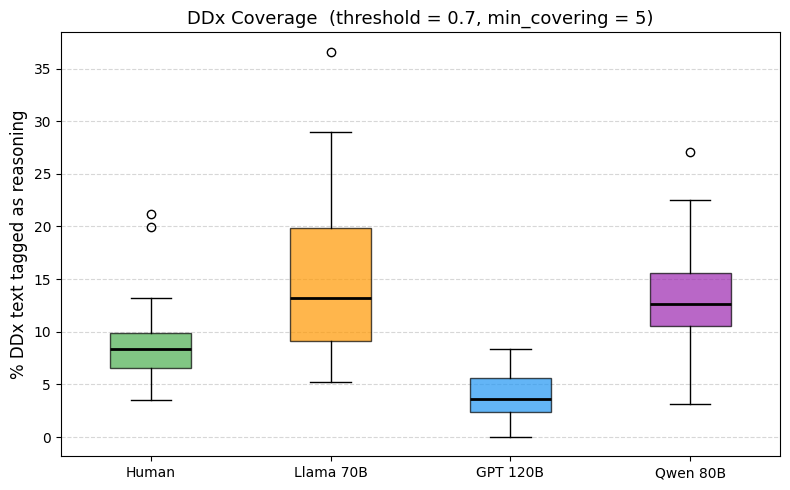

In [37]:
def compute_coverage(group_data: dict) -> list:
    """Per-case % of DDx characters covered by filtered segments."""
    coverages = []
    for case_data in group_data.values():
        segs    = case_data['segments']
        offset  = case_data['reasoning_offset']
        ddx_len = case_data['ddx_len']
        if ddx_len == 0:
            continue
        # Each segment may partially precede the DDx offset; clip accordingly.
        tagged = sum(max(0, s['end'] - max(s['start'], offset)) for s in segs)
        coverages.append(tagged / ddx_len * 100)
    return coverages


fig, ax = plt.subplots(figsize=(8, 5))
cov_data = [compute_coverage(data[g]) for g in GROUP_NAMES]
bp = ax.boxplot(cov_data, labels=GROUP_NAMES, patch_artist=True,
                medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], GROUP_COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel('% DDx text tagged as reasoning', fontsize=12)
ax.set_title(f'DDx Coverage  (threshold = {CONSENSUS_THRESHOLD}, min_covering = {MIN_COVERING})',
             fontsize=13)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig(plot_path('coverage'), dpi=150, bbox_inches='tight')
plt.show()

## 6 · Metric 2 — Macro Distribution (ABD / DED / IND)

One grouped barplot: 4 clusters (one per group), 3 bars per cluster.
Distributions are normalised within each group (% of total annotated segments).

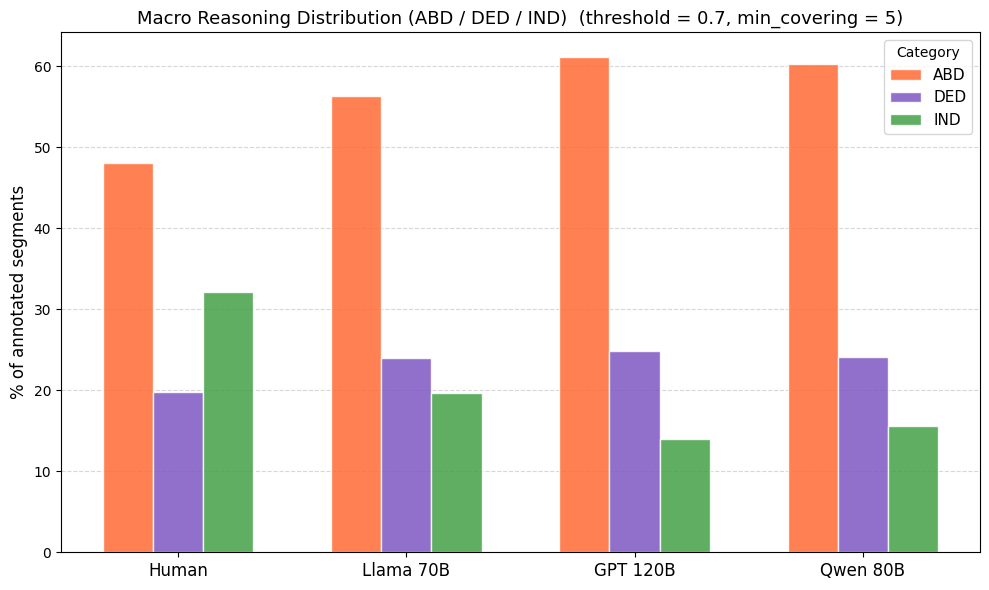

In [38]:
def compute_macro_dist(group_data: dict) -> dict:
    counts = defaultdict(int)
    for case_data in group_data.values():
        for seg in case_data['segments']:
            lbl = seg['winning_label']
            for macro, micro_list in MACRO.items():
                if lbl in micro_list:
                    counts[macro] += 1
    total = sum(counts.values()) or 1
    return {m: counts[m] / total * 100 for m in MACRO}


macro_dists = {g: compute_macro_dist(data[g]) for g in GROUP_NAMES}
macro_keys  = list(MACRO.keys())
x           = np.arange(len(GROUP_NAMES))
bar_w       = 0.22
n_macro     = len(macro_keys)
offsets     = np.linspace(-(n_macro - 1) / 2, (n_macro - 1) / 2, n_macro) * bar_w

fig, ax = plt.subplots(figsize=(10, 6))
for i, macro in enumerate(macro_keys):
    vals = [macro_dists[g][macro] for g in GROUP_NAMES]
    ax.bar(x + offsets[i], vals, bar_w, label=macro,
           color=MACRO_COLORS[macro], alpha=0.85, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(GROUP_NAMES, fontsize=12)
ax.set_ylabel('% of annotated segments', fontsize=12)
ax.set_title(
    f'Macro Reasoning Distribution (ABD / DED / IND)'
    f'  (threshold = {CONSENSUS_THRESHOLD}, min_covering = {MIN_COVERING})',
    fontsize=13,
)
ax.legend(title='Category', fontsize=11)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig(plot_path('macro'), dpi=150, bbox_inches='tight')
plt.show()

## 7 · Metric 3 — Micro Distribution (12 labels)

4 subplots (2 × 2), one per group. Bar colours match the comparison tool palette.  
Dashed vertical lines separate ABD / DED / IND blocks.

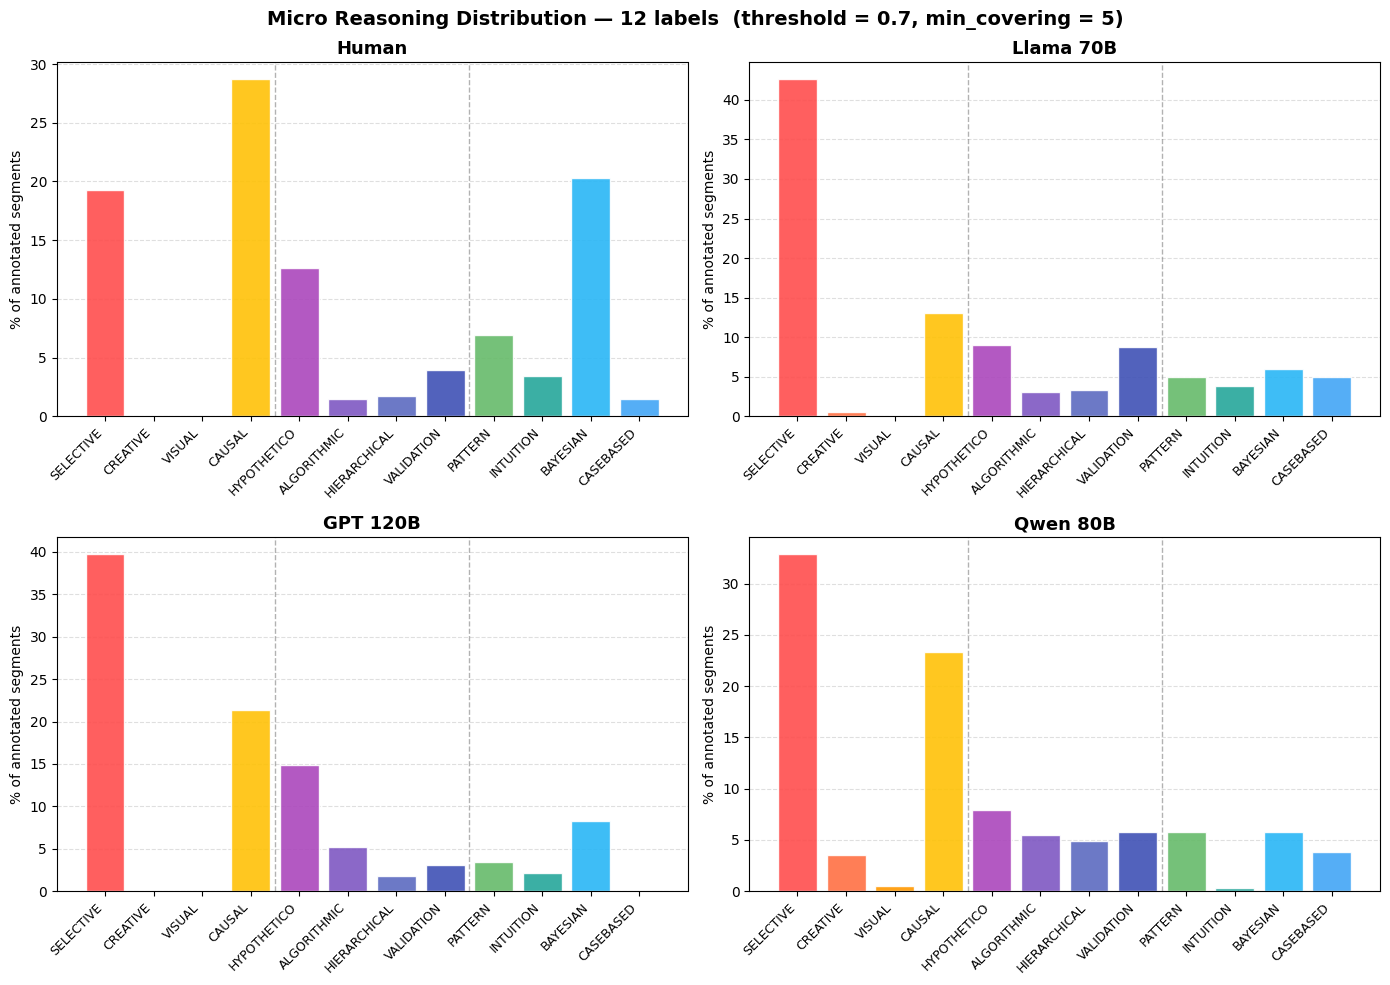

In [39]:
def compute_micro_dist(group_data: dict) -> dict:
    counts = defaultdict(int)
    for case_data in group_data.values():
        for seg in case_data['segments']:
            counts[seg['winning_label']] += 1
    total = sum(counts.values()) or 1
    return {lbl: counts.get(lbl, 0) / total * 100 for lbl in LABEL_ORDER}


short_names = [lbl.split('_', 1)[1] for lbl in LABEL_ORDER]   # e.g. 'SELECTIVE'
bar_colors  = [LABEL_COLORS[lbl] for lbl in LABEL_ORDER]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, group_name in zip(axes, GROUP_NAMES):
    dist = compute_micro_dist(data[group_name])
    vals = [dist[lbl] for lbl in LABEL_ORDER]
    ax.bar(range(len(LABEL_ORDER)), vals, color=bar_colors, edgecolor='white', alpha=0.9)
    ax.set_xticks(range(len(LABEL_ORDER)))
    ax.set_xticklabels(short_names, rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('% of annotated segments', fontsize=10)
    ax.set_title(group_name, fontsize=13, fontweight='bold')
    ax.yaxis.grid(True, linestyle='--', alpha=0.4)
    ax.set_axisbelow(True)
    # Separators between ABD/DED and DED/IND
    for boundary in [4, 8]:
        ax.axvline(boundary - 0.5, color='gray', linewidth=1.0, linestyle='--', alpha=0.6)

fig.suptitle(
    f'Micro Reasoning Distribution — 12 labels'
    f'  (threshold = {CONSENSUS_THRESHOLD}, min_covering = {MIN_COVERING})',
    fontsize=14, fontweight='bold',
)
plt.tight_layout()
plt.savefig(plot_path('micro'), dpi=150, bbox_inches='tight')
plt.show()

## 8 · Metric 4 — Inter-Judge Agreement (IAA)

For each case: the length-weighted mean agreement across all annotated segments,  
where agreement on a segment = (unique judges for winning label) / (total unique judges covering it).

**Interpretation**: lower IAA for LLM groups → jury finds LLM reasoning epistemically less legible.

/var/folders/rq/b2t2f_cn78xgsp6t5gr8rw3c0000gn/T/ipykernel_23655/378423395.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(iaa_data, labels=GROUP_NAMES, patch_artist=True,


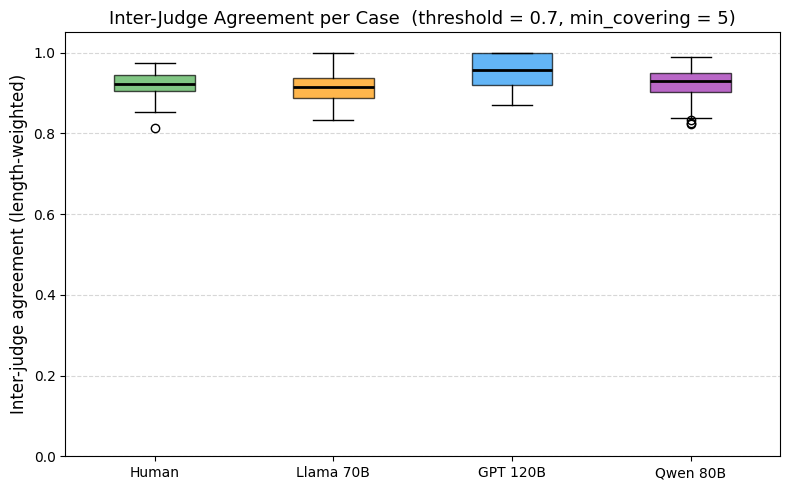

In [40]:
def compute_iaa_per_case(group_data: dict) -> list:
    iaas = []
    for case_data in group_data.values():
        weighted_sum = 0.0
        total_weight = 0
        for seg in case_data['segments']:
            weight = seg['end'] - seg['start']
            label_to_judges: dict = defaultdict(set)
            for judge_idx, labels in seg['judge_labels'].items():
                for lbl in labels:
                    label_to_judges[lbl].add(judge_idx)
            n_total = len(seg['judge_labels'])
            if n_total == 0:
                continue
            winning   = max(label_to_judges, key=lambda l: len(label_to_judges[l]))
            agreement = len(label_to_judges[winning]) / n_total
            weighted_sum += agreement * weight
            total_weight += weight
        if total_weight > 0:
            iaas.append(weighted_sum / total_weight)
    return iaas


fig, ax = plt.subplots(figsize=(8, 5))
iaa_data = [compute_iaa_per_case(data[g]) for g in GROUP_NAMES]
bp = ax.boxplot(iaa_data, labels=GROUP_NAMES, patch_artist=True,
                medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], GROUP_COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel('Inter-judge agreement (length-weighted)', fontsize=12)
ax.set_title(
    f'Inter-Judge Agreement per Case'
    f'  (threshold = {CONSENSUS_THRESHOLD}, min_covering = {MIN_COVERING})',
    fontsize=13,
)
ax.set_ylim(0, 1.05)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig(plot_path('iaa'), dpi=150, bbox_inches='tight')
plt.show()